In [10]:
import io
from datetime import date, timedelta

import numpy as np
import requests
from PIL import Image

EFFIS_WMS = "https://maps.effis.emergency.copernicus.eu/effis"
LAYER = "mf010.fwi"

# EFFIS European FWI danger classes
FWI_CLASSES = [
    (5.2, "very_low"),
    (11.2, "low"),
    (21.3, "moderate"),
    (38.0, "high"),
    (50.0, "very_high"),
    (float("inf"), "extreme"),
]


def fwi_class(value: float) -> str:
    for threshold, label in FWI_CLASSES:
        if value < threshold:
            return label
    return "extreme"


def query_fwi(lat: float, lon: float, target_date: date, layer: str = LAYER) -> float | None:
    """Sample the FWI value at (lat, lon) by reading the center pixel of a small
    GeoTIFF. Returns None on nodata. Raises on transport error."""
    half = 0.5
    grid = 11
    params = {
        "service": "WMS",
        "version": "1.1.1",
        "request": "GetMap",
        "layers": layer,
        "styles": "",
        "srs": "EPSG:4326",
        "bbox": f"{lon - half},{lat - half},{lon + half},{lat + half}",
        "width": grid,
        "height": grid,
        "format": "image/tiff",
        "time": target_date.isoformat(),
    }

    resp = requests.get(EFFIS_WMS, params=params, timeout=30)
    resp.raise_for_status()
    if not resp.headers.get("content-type", "").startswith("image"):
        raise RuntimeError(f"EFFIS error: {resp.text.strip()[:200]}")

    arr = np.array(Image.open(io.BytesIO(resp.content)))
    value = float(arr[grid // 2, grid // 2])

    if value < 0 or value > 200:
        return None
    # Disambiguate real zero from out-of-coverage. EFFIS renders nodata as
    # 0, so outside the Météo-France model domain the whole bbox is exactly
    # 0. Inside the domain, even a region with FWI ≈ 0 has tiny non-zero
    # neighbors from the model grid. If the entire window is strictly 0,
    # treat the sample as nodata.
    if value == 0 and float(arr.max()) == 0:
        return None
    return value


In [11]:


try:
    valeur_fwi = query_fwi(43.1055,2.6434,date(2025,8,5))
    
    if valeur_fwi is not None:
        classe = fwi_class(valeur_fwi)
    else:
        print("nodata")

except Exception as e:
    print(f"Erreur lors de la récupération des données : {e}")



In [153]:
import pandas as pd

df = pd.read_csv("data.csv")
top_communes = df['Nom de la commune'].value_counts().head(50).index.tolist()

In [43]:
resultats_fwi = []

start_date = date(2025, 1, 1)
end_date = date(2025, 12, 31)
delta = timedelta(days=1)
top_communes = ['Fontainebleau']
for commune in top_communes : 
    lat = float(df.loc[ df.index[df['Nom de la commune'] == commune], 'latitude'].head(1).iloc[0])
    lon = float(df.loc[ df.index[df['Nom de la commune'] == commune], 'longitude'].head(1).iloc[0])

    current_date = start_date
    while current_date <= end_date:

        try:
            score_fwi = query_fwi(lat, lon, current_date)

            resultats_fwi.append(
                {
                    "commune": commune,
                    "latitude": lat,
                    "longitude": lon,
                    "date": current_date,
                    "fwi": score_fwi,
                    "classe": fwi_class(score_fwi)
                }
            )
        except Exception as e:
            print(f"Erreur le {current_date} pour {commune} : {e}")

        current_date += delta

df_fwi = pd.DataFrame(resultats_fwi)

In [46]:
import matplotlib.pyplot as plt

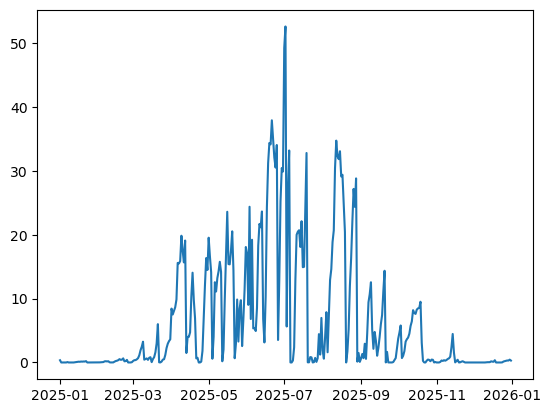

In [132]:
plt.plot(df_fwi.index, df_fwi['fwi'])

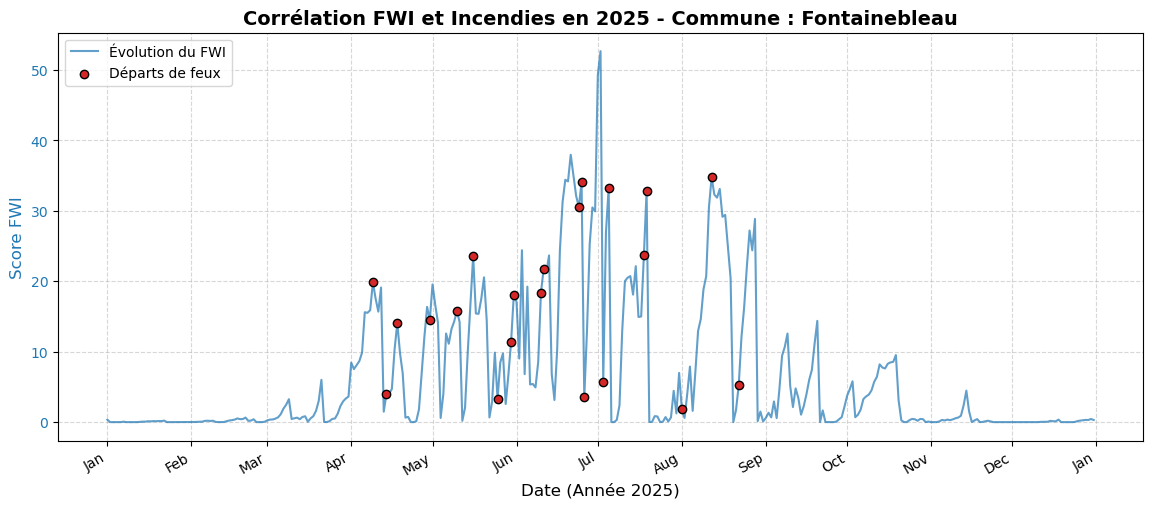

In [166]:
import matplotlib.dates as mdates
import matplotlib.pyplot as plt

nom_commune = "Fontainebleau"


df_feux_commune = df[df["Nom de la commune"] == nom_commune]

fwi = {}
for idx, row in df_feux_commune.iterrows() :
     fwi[row['date']] = df_fwi.loc[row['date'], 'fwi']
    
df_fwi_commune = pd.DataFrame.from_dict(fwi, orient="index", columns=["fwi"])

fig, ax1 = plt.subplots(figsize=(14, 6))

#evolution continue de fwi
ax1.plot(
    df_fwi.index,
    df_fwi["fwi"],
    color="tab:blue",
    label="Évolution du FWI",
    alpha=0.7,
)
ax1.set_ylabel("Score FWI", color="tab:blue", fontsize=12)
ax1.tick_params(axis="y", labelcolor="tab:blue")

#feux répertoriés
ax1.scatter(
    df_fwi_commune.index,
    df_fwi_commune["fwi"],
    color="tab:red",
    #s=df["Surface parcourue (m2)"]* 5,  #surface proportionnelle à la superficie détruite
    label="Départs de feux",
    edgecolors="black",
    zorder=5,  # Pour que les points passent au-dessus de la ligne
)


ax1.set_title(
    f"Corrélation FWI et Incendies en 2025 - Commune : {nom_commune}",
    fontsize=14,
    fontweight="bold",
)
ax1.set_xlabel("Date (Année 2025)", fontsize=12)

ax1.xaxis.set_major_locator(mdates.MonthLocator())
ax1.xaxis.set_major_formatter(mdates.DateFormatter("%b"))
fig.autofmt_xdate()  # Incline les dates si besoin

ax1.grid(True, linestyle="--", alpha=0.5)
ax1.legend(loc="upper left")

plt.show()